## Задание 1. Создание нейросети в Scikit learn

Используя возможности библиотеки scikit learn разработайте простую нейронную сеть (многослойный персептрон), используя один из датасетов предложенных преподавателем или собственный датасет. При реализации задания необходимо выполнить следующие этапы:
подготовка обучающих данных;
создание нейросети;
подбор гиперпараметров с помощью GridSearchCV или RandomizedSearchCV;
обучение нейросети;
визуализация результатов и подсчет метрик качества.
*Примечание: для выполнения задания можно использовать возможности библиотек, изученных ранее (numpy, pandas, Matplotlib, seaborn).*

In [6]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

In [7]:
df = pd.read_csv("weather.csv")
display(df.shape)
display(df.describe(include="all"))
display(df.isna().sum().to_frame("Пропущенные значения"))


(145460, 23)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,145460,145460,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135134,135197.000000,134894,...,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000,142199,142193
unique,3436,49,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,2013-03-01,Canberra,NaN,NaN,NaN,NaN,NaN,W,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No
freq,49,3436,NaN,NaN,NaN,NaN,NaN,9915,NaN,11758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110319,110316
mean,NaN,NaN,12.194034,23.221348,2.360918,5.468232,7.611178,NaN,40.035230,NaN,...,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339,NaN,NaN
std,NaN,NaN,6.398495,7.119049,8.478060,4.193704,3.785483,NaN,13.607062,NaN,...,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665,NaN,NaN
min,NaN,NaN,-8.500000,-4.800000,0.000000,0.000000,0.000000,NaN,6.000000,NaN,...,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000,NaN,NaN
25%,NaN,NaN,7.600000,17.900000,0.000000,2.600000,4.800000,NaN,31.000000,NaN,...,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000,NaN,NaN
50%,NaN,NaN,12.000000,22.600000,0.000000,4.800000,8.400000,NaN,39.000000,NaN,...,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000,NaN,NaN
75%,NaN,NaN,16.900000,28.200000,0.800000,7.400000,10.600000,NaN,48.000000,NaN,...,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000,NaN,NaN


,Пропущенные значения
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


                MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  \
MinTemp        1.000000  0.736555  0.103938     0.466993  0.072586   
MaxTemp        0.736555  1.000000 -0.074992     0.587932  0.470156   
Rainfall       0.103938 -0.074992  1.000000    -0.064351 -0.227549   
Evaporation    0.466993  0.587932 -0.064351     1.000000  0.365602   
Sunshine       0.072586  0.470156 -0.227549     0.365602  1.000000   
WindGustSpeed  0.177415  0.067615  0.133659     0.203021 -0.034750   
WindSpeed9am   0.175064  0.014450  0.087338     0.193084  0.005499   
WindSpeed3pm   0.175173  0.050300  0.057887     0.129400  0.053834   
Humidity9am   -0.232899 -0.504110  0.224405    -0.504092 -0.490819   
Humidity3pm    0.006089 -0.508855  0.255755    -0.390243 -0.629130   
Pressure9am   -0.450970 -0.332061 -0.168154    -0.270362  0.041970   
Pressure3pm   -0.461292 -0.427167 -0.126534    -0.293581 -0.019719   
Cloud9am       0.078754 -0.289370  0.198528    -0.183793 -0.675323   
Cloud3pm       0.021

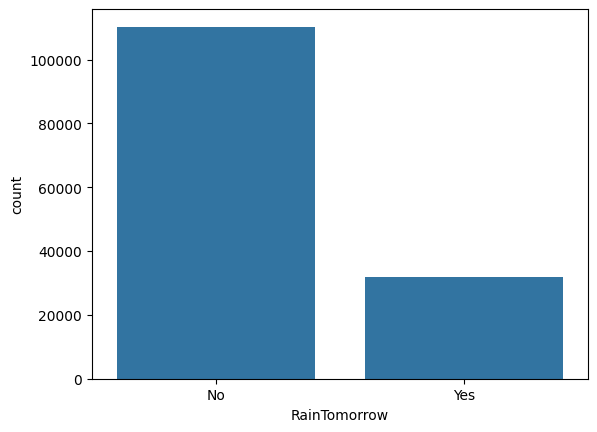

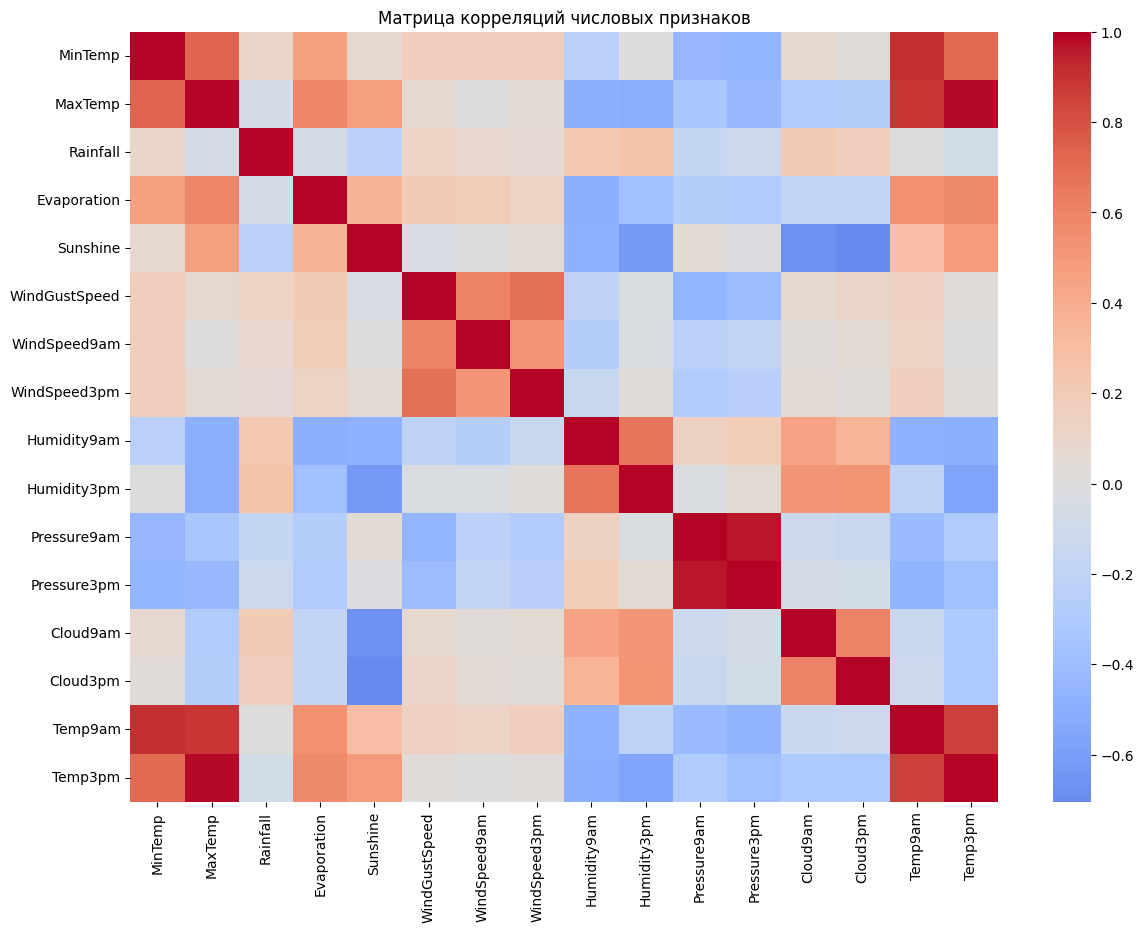

In [8]:
sns.countplot(data=df, x='RainTomorrow')

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Матрица корреляций числовых признаков')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


df = df.drop(columns=["Sunshine", "Evaporation"])

# Удаляем строки без целевой
df = df.dropna(subset=['RainTomorrow'])

df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})


df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df = df.drop(columns=['Date'])

X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']


numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(random_state=42, max_iter=300))
])

param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,)],
    'classifier__activation': ['relu'],
    'classifier__alpha': [0.0001, 0.001],
    # 'classifier__learning_rate_init': [0.001, 0.01]
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
from sklearn.model_selection import GridSearchCV
import joblib

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=2
# )

# grid_search.fit(X_train, y_train)

# print("Лучшие параметры:")
# print(grid_search.best_params_)

# print("Лучший score на кросс-валидации:")
# print(grid_search.best_score_)

# joblib.dump(grid_search.best_estimator_, 'best_mlp.pkl')

In [12]:
# import pandas as pd

# results = pd.DataFrame(grid_search.cv_results_)
# print(results[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head())

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

best_model = joblib.load('best_mlp.pkl')
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"Classification report: {classification_report(y_test, y_pred)}\n")
print(f"Confusion matrix: {confusion_matrix(y_test, y_pred)}\n")

Accuracy: 0.8541087942614016
Classification report:               precision    recall  f1-score   support

           0       0.89      0.93      0.91     22064
           1       0.70      0.60      0.65      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.76      0.78     28439
weighted avg       0.85      0.85      0.85     28439


Confusion matrix: [[20451  1613]
 [ 2536  3839]]



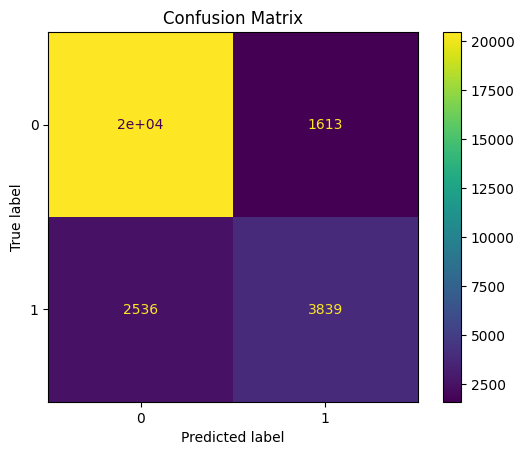

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

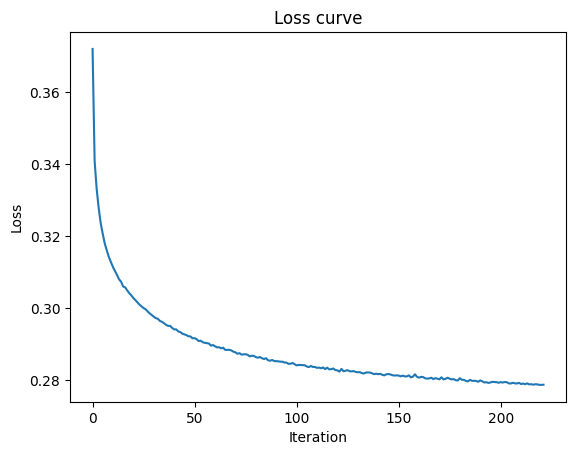

In [15]:
mlp = best_model.named_steps['classifier']
plt.plot(mlp.loss_curve_)
plt.title('Loss curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

## Задание 2. Алгоритм обратного распространения ошибки

---

В данном задании Вам нужно будет:
- дополнить класс **`Neuron()`** с функцией активации ReLU, чтобы в нём было запрограмировано обучение нейронной сети по методу обратного распространения ошибки (прямой и обратный проход по сети)

- обучить и протестировать этот класс на сгенерированных и реальных данных

In [16]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---

В данном случае мы решаем задачу бинарной классификации (2 класса: 1 или 0). Для простоты в качестве функции потерь возьмём квадратичную функцию потерь, хоть она и плохо показывает себя в задаче классификации.

$$
Loss(\hat{y}, y) = \frac{1}{n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2
$$  

Здесь $w \cdot X_i$ - скалярное произведение, а $\hat{y_i} = \sigma(w \cdot X_i ), а \  \sigma$- функция активации ($i$ -- номер объекта в выборке).

In [17]:
def Loss(y_pred, y):
    y_pred = y_pred.reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)
    return 0.5 * np.mean((y_pred - y) ** 2)

<h2 style="text-align: center;"><b>Нейрон с ReLU (Recitified Linear Unit)</b></h2>  

ReLU самая часто используемая (по крайней мере, пару лет назад) функция активации в нейронных сетях. Выглядит она очень просто:

\begin{equation*}
ReLU(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Или по-другому:

$$
ReLU(x) = \max(0, x)
$$

В (свободном) переводе Rectified Linear Unit = "Усечённая линейная функция". Собственно, мы по сути просто не даём проходить отрицательным числам.

Производная здесь берётся как производная от кусочно-заданной функции, то есть на участках, где функция гладкая, и в нуле её доопредляют нулём:

\begin{equation*}
ReLU'(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим ReLu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ReLU(w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
    y_i^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

(помните, что $w \cdot X_i$ -- это число в данном случае (результат скалярного произведения двух векторов)).

Тогда формула для обновления весов при градиентном спуске будет такая (в матричном виде, рекмендуем вывести самим то, как это получается из формулы для одного объекта):

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   0, &{w \cdot X_i \le 0}\\
   \frac{1}{n} X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

(напоминаем, что здесь $w \cdot X$ -- матричное произведение вектора $w$ (ведь вектор -- тоже матрица, не так ли?) и матрицы $X$ )

Почему в первом случае будет 0? Потому что в формулу $y_i^2$ не входят веса , а мы берём производную именно по весам $w$.

* Реализуйте ReLU и её производную:

In [18]:
def relu(x):
    """ReLU-функция"""
    return np.maximum(0, x)

In [19]:
def relu_derivative(x):
    """Производная ReLU"""
    return (x > 0).astype(float)

Теперь нужно написать класс нейрон с ReLU:

In [ ]:
class NeuronReLU:
    def __init__(self, w=None, b=0):
        """
        :param: w -- вектор весов
        :param: b -- смещение
        """
        self.w = w
        self.b = b


    def activate(self, x):
        return relu(x)


    def forward_pass(self, X):
        """
        Рассчитывает ответ нейрона при предъявлении набора объектов
        :param: X -- матрица примеров размера (n, m), каждая строка - отдельный объект
        :return: вектор размера (n, 1) из нулей и единиц с ответами нейрона
        """
        return self.activate(X @ self.w + self.b)  # y_pred == y_predicted - предсказанные классы
        

    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        """
        Обновляет значения весов нейрона в соответствии с этим объектом
        :param: X -- матрица входов размера (n, m)
                y -- вектор правильных ответов размера (n, 1)
                learning_rate - "скорость обучения" (символ alpha в формулах выше)
        В этом методе ничего возвращать не нужно, только правильно поменять веса
        с помощью градиентного спуска.
        """
        n = len(y)
        y = np.array(y).reshape(-1, 1)
        
        delta = (1 / n) * (y_pred - y) * relu_derivative(X @ self.w + self.b)
        self.w -= learning_rate * (X.T @ delta)
        self.b -= learning_rate * np.sum(delta)


    def fit(self, X, y, num_epochs=300):
        """
        Спускаемся в минимум
        :param: X -- матрица объектов размера (n, m)
                y -- вектор правильных ответов размера (n, 1)
                num_epochs -- количество итераций обучения
        :return: losses -- вектор значений функции потерь
        """
        # self.w = np.zeros((X.shape[1], 1))  # столбец (m, 1)
        # self.b = 0  # смещение (число)
        Loss_values = []  # значения функции потерь на различных итерациях обновления весов

        for i in range(num_epochs):
            y_pred = self.forward_pass(X)
            Loss_values.append(Loss(y_pred, y))
            self.backward_pass(X,y, y_pred)

        return Loss_values

<h3 style="text-align: center;"><b>Тестирование нейрона с ReLU</b></h3>  

Здесь Вам нужно самим протестировать новый нейрон **на данных** ("Яблоки и Груши").
В итоге нужно вывести:
* график, на котором будет показано, как изменяется функция потерь $Loss$ в зависимости от числа итераций обучения
* график с раскраской выборки нейроном

***ПРИМЕЧАНИЕ***: пожалуйста, почаще проверяйте `.shape` у матриц и векторов: `self.w`, `X` и `y` внутри класса. Очень часто ошибка решается транспонированием или `.reshape()`'ом. Не забывайте проверять, что на что Вы умножаете и какой вектор (какой размер) хотите получить на выходе -- это очень помогает не запутаться.

** Проверка forward_pass()**

In [21]:
w = np.array([1., 2.]).reshape(2, 1)
b = 2.
X = np.array([[1., 3.],
              [2., 4.],
              [-1., -3.2]])

neuron = NeuronReLU(w, b)
y_pred = neuron.forward_pass(X)
print ("y_pred = " + str(y_pred))

y_pred = [[ 9.]
 [12.]
 [ 0.]]


*Hint: "**-0.**" -- это просто ноль*

**Проверка backward_pass()**

In [22]:
y = np.array([1, 0, 1]).reshape(3, 1)

In [23]:
neuron.backward_pass(X, y, y_pred)

print ("w = " + str(neuron.w))
print ("b = " + str(neuron.b))

w = [[0.89333333]
 [1.76      ]]
b = 1.9333333333333333


"Яблоки и Груши" (необходимо положить данные в папку `./data`):

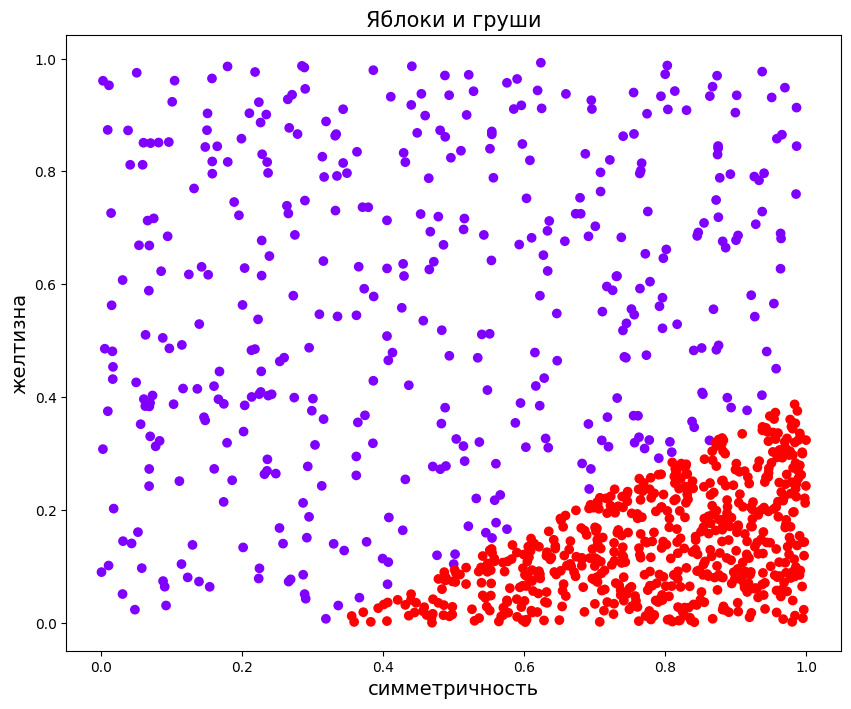

In [24]:
data = pd.read_csv("./data/apples_pears.csv")
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['target'], cmap='rainbow')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

In [25]:
X = data.iloc[:,:2].values  # матрица объекты-признаки
y = data['target'].values.reshape((-1, 1))  # классы (столбец из нулей и единиц)

Выведите лосс при обучении нейрона с ReLU на этом датасете:

<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_39416/4193100989.py:8: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$Loss(\hat{y}, y)$', fontsize=14)


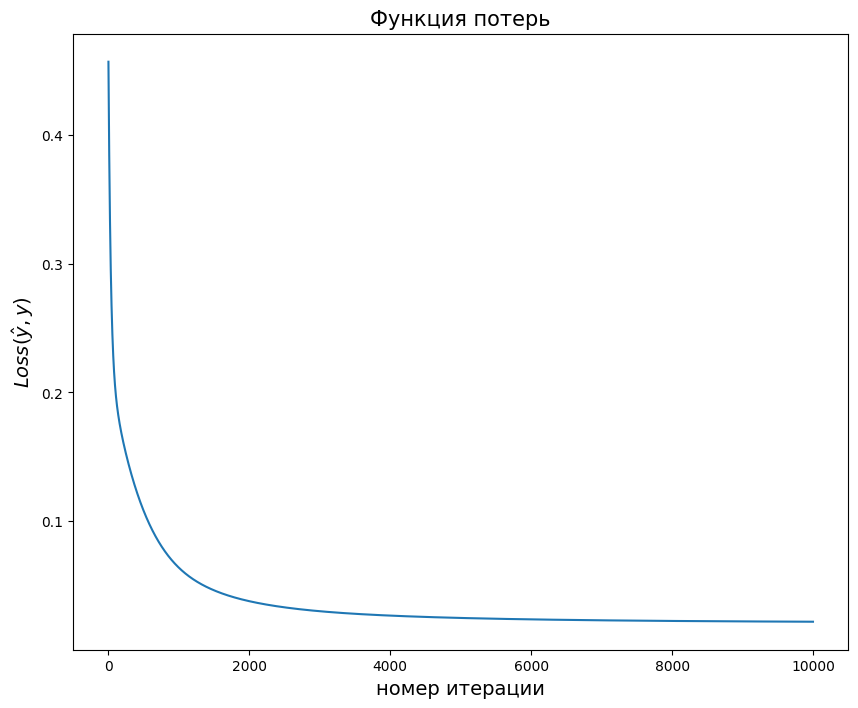

In [26]:
neuron = NeuronReLU(w=np.random.rand(X.shape[1], 1), b=np.random.rand(1))
Loss_values = neuron.fit(X, y, num_epochs=10000)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values)
plt.title('Функция потерь', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\hat{y}, y)$', fontsize=14)
plt.show()

Скорее всего сейчас у вас лосс -- это прямая линия, и вы видите, что веса не обновляются. Но почему?

Всё просто -- если присмотреться, то видно, что self.w и self.b иницилизируются нулями в начале `.fit()`-метода. Если расписать, как будет идти обновление, то видно, что из-за ReLU веса просто-напросто не будут обновляться, если начать с инициализации нулями.

Это -- одна из причин, по которой в нейронных сетях веса инициализируют случайными числами (обычно из отрезка [0, 1)).

Обучим нейрон, инициализировав случайно веса (поставьте 10000 итераций).

**!!! Закомментируйте инициализацию нулями в функции `.fit()` класса `NeuronReLU` !!!**

<unknown>:8: SyntaxWarning: invalid escape sequence '\h'


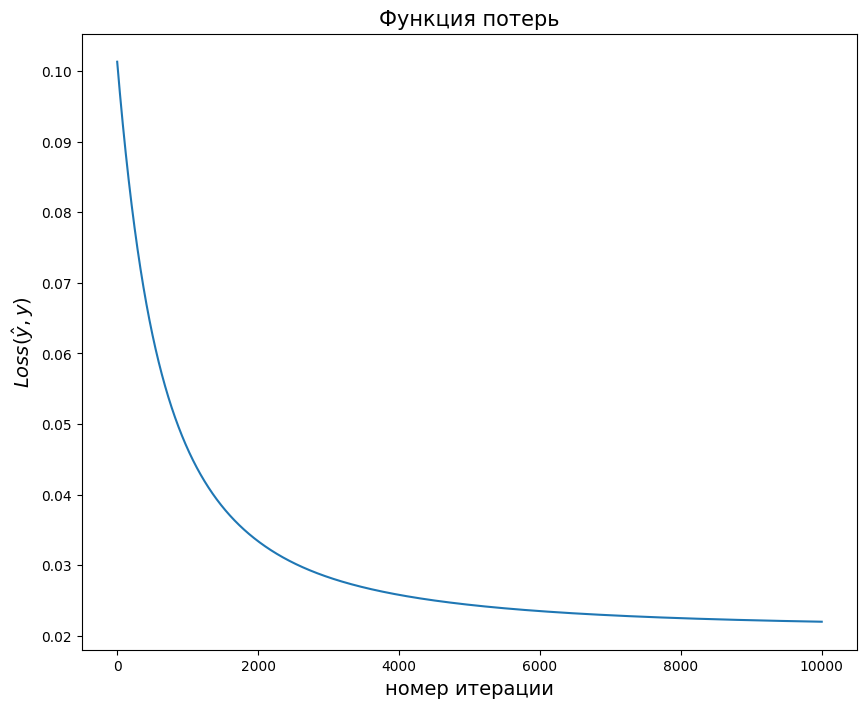

CPU times: user 469 ms, sys: 2.15 ms, total: 472 ms
Wall time: 470 ms


In [27]:
%%time

neuron = NeuronReLU(w=np.random.rand(X.shape[1], 1), b=np.random.rand(1))
Loss_values = neuron.fit(X, y, num_epochs=10000)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values)
plt.title('Функция потерь', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\hat{y}, y)$', fontsize=14)
plt.show()

Посмотрим, как предсказывает этот нейрон:

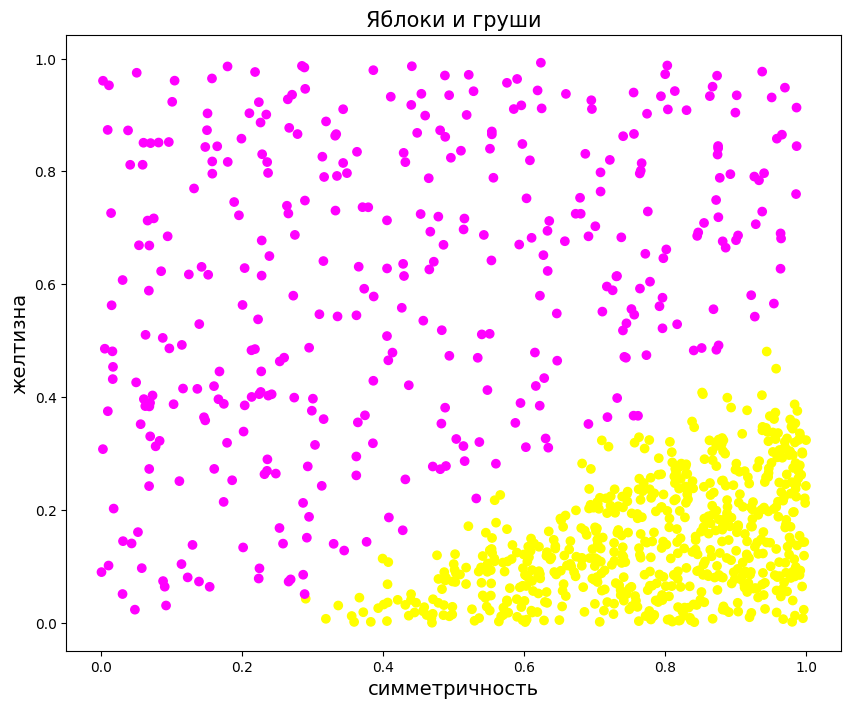

In [28]:
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=np.array(neuron.forward_pass(X) > 0.5).ravel(), cmap='spring')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

Есть одна тенденция: пороговая функция активации и сигмоида (обычно всё же только сигмоида) чаще используются именно на **выходном слое** нейросети в задаче классификации -- ими предсказывают вероятности объектов принадлежать одному из классов, в то время как продвинутые функции активации (ReLU и те, что будут дальше) используются внутри нейросети, то есть в **скрытых слоях**.

Нужно понимать, что ReLU не может вернуть отрицательные числа.

**Плюсы ReLU:**

* дифференцируемая (с доопределением в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде

**Возможные минусы ReLU:**

* не центрирована около 0 (может мешать скорости сходимости)
* зануляет все отрицательные входы, тем самым веса у занулённых нейронов могут часто *не обновляться*, эту проблему иногда называют *мёртвые нейроны*

С последней проблемой можно побороться, а именно:

<h2 style="text-align: center;"><b>Нейрон с LeakyReLU (Leaky Recitified Linear Unit)</b></h2>  

LeakyReLU очень слабо отличается от ReLU, но часто помогает сети обучаться быстрее, поскольку нет проблемы "мёртвых нейронов":

\begin{equation*}
LeakyReLU(x) =
 \begin{cases}
   \alpha x, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
LeakyReLU'(x) =
 \begin{cases}
   \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим LeakyReLu в Loss:

$$
Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (LeakyReLU(w \cdot X_i) - y_i)^2 =
\begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha \cdot w \cdot X_i - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}
$$  

Формула для обновления весов при градиентном спуске:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   \alpha X_i^T (w \cdot X_i - y), &{w \cdot X_i \le 0}\\
    X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$


**Плюсы LeakyReLU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU

**Возможные минусы LeakyReLU:**

* не центрирована около 0 (может мешать скорости сходимсти)
* немного не устойчива к "шуму" (см. лекции Стэнфорда)

<h2 style="text-align: center;"><b>Нейрон с ELU (Exponential Linear Unit)</a></b></h2>  

ELU -- не так давно предложенная (в 2015 году) функция активации, которая, как говорят авторы статьи, лучше LeakyReLU. Вот формула ELU:

\begin{equation*}
ELU(\alpha, x) =
 \begin{cases}
   \alpha (e^x - 1), &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
ELU'(x) =
 \begin{cases}
   ELU(\alpha, x) + \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Здесь в производной использован постой трюк -- сделано $- \alpha + \alpha$, чтобы вычислять было проще.

График этой функции:

<img src="http://p0.ifengimg.com/pmop/2017/0907/A004001DD141881BFD8AD62E5D31028C3BE3FAD1_size14_w446_h354.png" width=500 height=400>

Подставим ELu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ELU(\alpha, w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha (e^{w \cdot X_i} - 1) - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

Здесь вам нужно выписать самим град спуск для весов. Брать производную "в лоб" некрасиво и неудобно. Нужно воспользоваться **правилом цепочки**, оно же **правило взятия производной сложной функции**:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   , &{w \cdot X_i \le 0}\\
   , &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

**Плюсы ELU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU
* более устойчива к "шуму" (см. лекции Стэнфорда)

**Возможные минусы ELU:**

* не очень хорошо центрирована около 0 (может мешать скорости сходимсти)
* вычислительно дольше, чем ReLU и LeakyReLU

---

И напоследок -- ещё интересные функции активации:

`SeLU()` и `Swish()`. Про них можно прочитать здесь: [SeLU](https://arxiv.org/pdf/1706.02515.pdf), [Swish](https://arxiv.org/pdf/1710.05941.pdf).

За функцию активации можно взять вообще почти любую функцию (которая, как вы полагаете, будет помогать обучению). Ещё больше функций активации вы можете [найти на википедии](https://en.wikipedia.org/wiki/Activation_function).

## Задание 3. Нейрон с различными функциями активации

Реализуйте предыдущее задание с помощью функций активации LeakyReLU и ELU. Сравните результаты

In [29]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)


def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1.0, alpha)


def elu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))


def elu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1.0, elu(x, alpha) + alpha)


class ActivationNeuron:
    def __init__(self, activation, activation_derivative, w=None, b=0):
        self.activation = activation
        self.activation_derivative = activation_derivative
        self.w = w
        self.b = b

    def forward_pass(self, X):
        return self.activation(X @ self.w + self.b)

    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        y = np.array(y).reshape(-1, 1)
        z = X @ self.w + self.b
        delta = (2 / len(y)) * (y_pred - y) * self.activation_derivative(z)
        self.w -= learning_rate * (X.T @ delta)
        self.b -= learning_rate * np.sum(delta)

    def fit(self, X, y, num_epochs=300, learning_rate=0.005):
        if self.w is None:
            self.w = np.random.rand(X.shape[1], 1)
        if self.b is None:
            self.b = 0

        losses = []
        for _ in range(num_epochs):
            y_pred = self.forward_pass(X)
            losses.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred, learning_rate=learning_rate)
        return losses


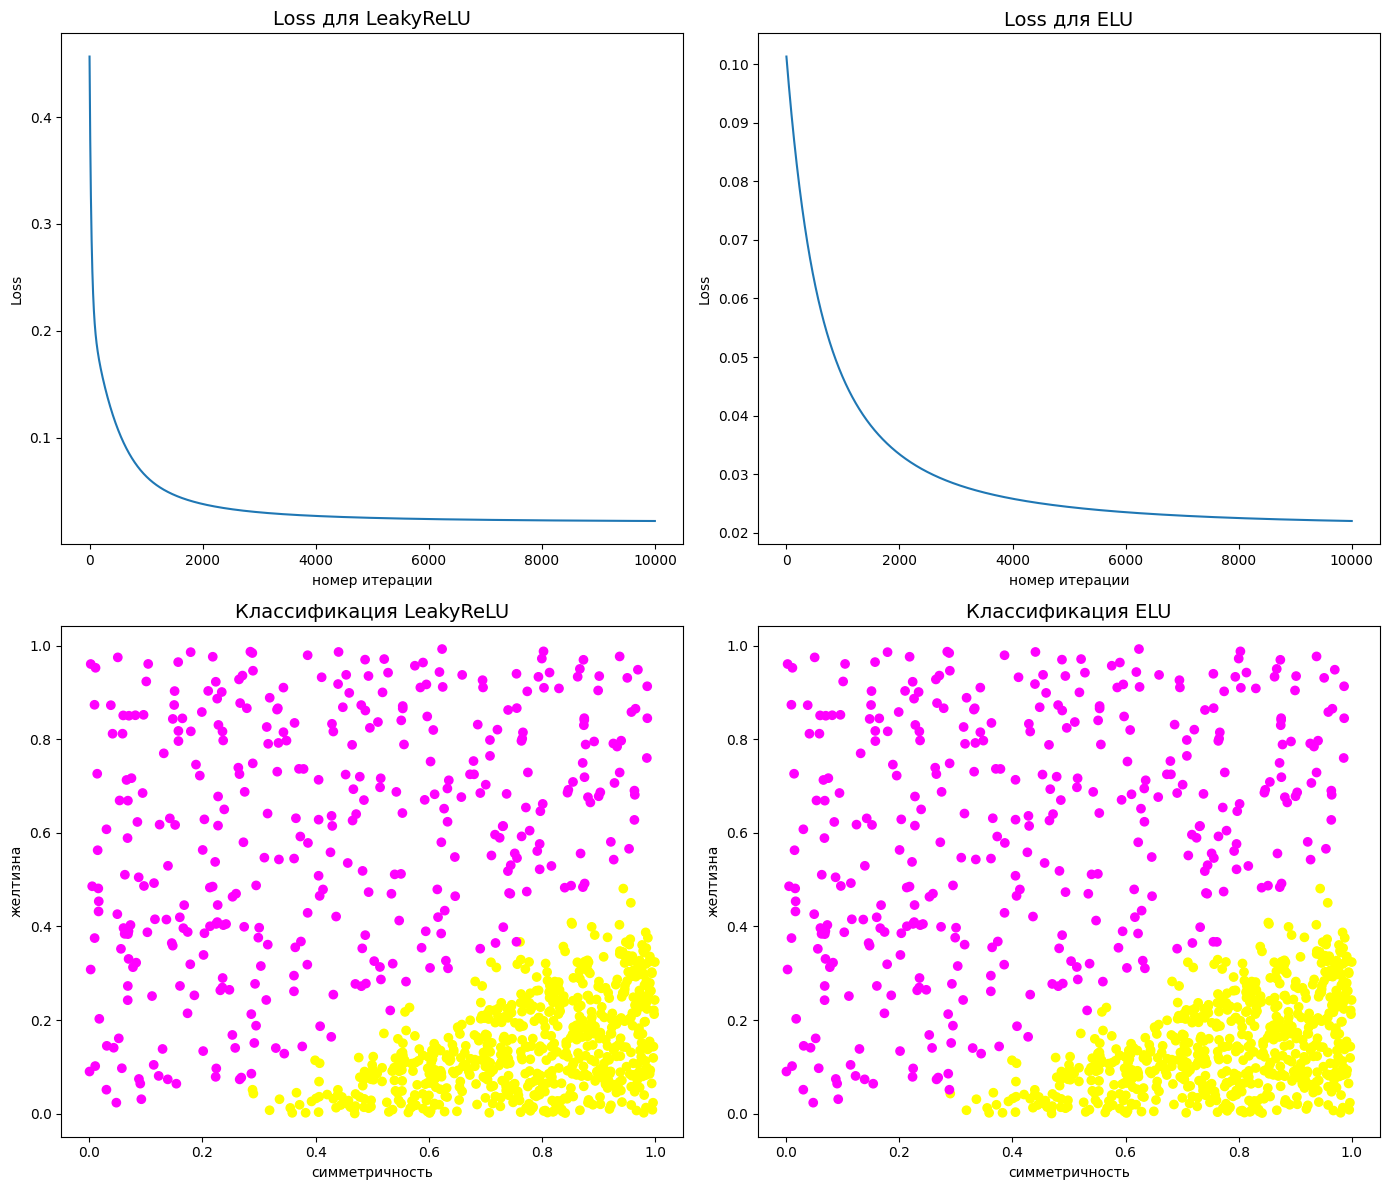

LeakyReLU: финальный loss = 0.022107
ELU:       финальный loss = 0.021994


In [30]:
np.random.seed(RANDOM_SEED)

leaky_neuron = ActivationNeuron(
    activation=lambda x: leaky_relu(x, alpha=0.01),
    activation_derivative=lambda x: leaky_relu_derivative(x, alpha=0.01),
    w=np.random.rand(X.shape[1], 1),
    b=np.random.rand(1)
)

elu_neuron = ActivationNeuron(
    activation=lambda x: elu(x, alpha=0.01),
    activation_derivative=lambda x: elu_derivative(x, alpha=0.01),
    w=np.random.rand(X.shape[1], 1),
    b=np.random.rand(1)
)

leaky_losses = leaky_neuron.fit(X, y, num_epochs=10000)
elu_losses = elu_neuron.fit(X, y, num_epochs=10000)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))


#LReLU
axes[0, 0].plot(leaky_losses)
axes[0, 0].set_title('Loss для LeakyReLU', fontsize=14)
axes[0, 0].set_xlabel('номер итерации')
axes[0, 0].set_ylabel('Loss')

axes[1, 0].scatter(
    data.iloc[:, 0],
    data.iloc[:, 1],
    c=(leaky_neuron.forward_pass(X) > 0.5).ravel(),
    cmap='spring'
)
axes[1, 0].set_title('Классификация LeakyReLU', fontsize=14)
axes[1, 0].set_xlabel('симметричность')
axes[1, 0].set_ylabel('желтизна')

#ELU
axes[0, 1].plot(elu_losses)
axes[0, 1].set_title('Loss для ELU', fontsize=14)
axes[0, 1].set_xlabel('номер итерации')
axes[0, 1].set_ylabel('Loss')

axes[1, 1].scatter(
    data.iloc[:, 0],
    data.iloc[:, 1],
    c=(elu_neuron.forward_pass(X) > 0.5).ravel(),
    cmap='spring'
)
axes[1, 1].set_title('Классификация ELU', fontsize=14)
axes[1, 1].set_xlabel('симметричность')
axes[1, 1].set_ylabel('желтизна')

plt.tight_layout()
plt.show()

print(f'LeakyReLU: финальный loss = {leaky_losses[-1]:.6f}')
print(f'ELU:       финальный loss = {elu_losses[-1]:.6f}')


## Задание 4. Сравнение собственной реализации с библиотечной

Сравните качество работы Вашего персептрона (с любой функцией активации) и алгоритма из библиотеки `sklearn` на датасете с сайта [Kaggle](https://www.kaggle.com) - [Gender Recognition by Voice](https://www.kaggle.com/primaryobjects/voicegender). (Код можно взять из файла Introducing_Scikit_Learn). Можно доработать собственную реализацию персептрона, сделав из него многослойный персептрон.

In [31]:
import pandas as pd
from sklearn.linear_model import Perceptron as skPerceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

data_path = './data/voice.csv'
data = pd.read_csv(data_path)
data['label'] = data['label'].apply(lambda x: 1 if x == 'male' else 0)

data.head()

RANDOM_SEED = 42


# Чтобы перемешать данные. Изначально там сначала идут все мужчины, потом все женщины
data = data.sample(frac=1, random_state=RANDOM_SEED)


X_train, X_test, y_train, y_test = train_test_split(data.iloc[:, :-1], data.iloc[:, -1], random_state=RANDOM_SEED, stratify=data.iloc[:, -1])


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [32]:

sk_perceptron = skPerceptron(random_state=RANDOM_SEED)
sk_perceptron.fit(X_train, y_train)

y_pred_sk = sk_perceptron.predict(X_test)
print('Точность (доля правильных ответов) перцептрона из sklearn: {:.3f} %'.format(
    accuracy_score(y_test, sk_perceptron.predict(X_test)) * 100))

Точность (доля правильных ответов) перцептрона из sklearn: 96.338 %


In [34]:
neuron = ActivationNeuron(
    activation=lambda x: leaky_relu(x, alpha=0.01),
    activation_derivative=lambda x: leaky_relu_derivative(x, alpha=0.01),
    w=np.random.rand(X_train.shape[1], 1),
    b=np.random.rand(1)
)

neuron.fit(X_train, y_train, num_epochs=10000, learning_rate=0.001)
y_pred_custom = (neuron.forward_pass(X_test) > 0.5).astype(int).ravel()

print('Точность (доля правильных ответов) перцептрона: {:.3f} %'.format(
    accuracy_score(y_test, y_pred_custom) * 100))


Точность (доля правильных ответов) перцептрона: 97.096 %


<h3 style="text-align: center;"><b>Полезные ссылки</b></h3>

0). Статья от Стэнфорда: http://cs231n.github.io/neural-networks-1/

1). Хорошая статья про функции активации: https://www.jeremyjordan.me/neural-networks-activation-functions/

2). [Видео от Siraj Raval](https://www.youtube.com/watch?v=-7scQpLossT7uo)

3). Современная статья про функции активации. Теперь на хайпе активация $swish(x) = x\sigma (\beta x)$: https://arxiv.org/pdf/1710.05941.pdf (кстати, при её поиске в некоторой степени использовался neural architecture search)

4). SeLU имеет очень интересные, доказанные с помощью теории вероятностей свойства: https://arxiv.org/pdf/1706.02515.pdf (да, в этой статье 102 страницы)

5). [Список функций активации из википедии](https://en.wikipedia.org/wiki/Activation_function)